<a href="https://colab.research.google.com/github/Annsjana123/Student-Performance-Analysis/blob/main/Students_Performance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **IMPORT LIBRARIES**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize']=(8,5)
sns.set_style("whitegrid")

# **LOAD DATASET**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Students_Performance/StudentsPerformance.csv')
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


# **DATA EXPLORATION & CLEANING**

In [ ]:
#Shape of Dataset
print("Rows and Columns:", df.shape)

Rows and Columns: (1000, 8)


In [ ]:
#Data Types
df.dtypes

,0
gender,object
race/ethnicity,object
parental level of education,object
lunch,object
test preparation course,object
math score,int64
reading score,int64
writing score,int64


In [ ]:
#Null Values
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [ ]:
#Duplicate Records
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [ ]:
#Basic Statistics
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [ ]:
#5 Line Dataset Summary
print(f"Dataset contains {df.shape[0]} students and {df.shape[1]} features.")
print("No missing values found in the dataset.")
print("The dataset includes demographic and academic information.")
print("Scores are available for Math, Reading, and Writing.")
print("Factors such as gender, parental education, lunch type, and test preparation are included.")

Dataset contains 1000 students and 8 features.
No missing values found in the dataset.
The dataset includes demographic and academic information.
Scores are available for Math, Reading, and Writing.
Factors such as gender, parental education, lunch type, and test preparation are included.


# **CREATE TOTAL SCORE**

In [ ]:
df['total_score'] = (
    df['math score'] +
    df['reading score'] +
    df['writing score']
)

# **FACTOR ANALYSIS QUESTIONS**

##**Q1 Does parental education affect scores?**


In [ ]:
parent_score = df.groupby(
    'parental level of education'
)[['math score','reading score','writing score']].mean()

parent_score.sort_values('math score')

,math score,reading score,writing score
parental level of education,,,
high school,62.137755,64.704082,62.448980
some high school,63.497207,66.938547,64.888268
some college,67.128319,69.460177,68.840708
associate's degree,67.882883,70.927928,69.896396
bachelor's degree,69.389831,73.000000,73.381356
master's degree,69.745763,75.372881,75.677966


**OBSERVATION:-** Students whose parents have bachelor's or master's degrees generally score higher than students whose parents have lower educational qualifications.

##**Q2 Do students who complete test prep score higher?**

In [ ]:
prep_score = df.groupby(
    'test preparation course'
)[['math score','reading score','writing score']].mean()

prep_score

,math score,reading score,writing score
test preparation course,,,
completed,69.695531,73.893855,74.418994
none,64.077882,66.534268,64.504673


**OBSERVATION:-** Students who completed the test preparation course perform better across all subjects.

##**Q3 Correlation between Reading, Writing and Math**

In [ ]:
df[['math score','reading score','writing score']].corr()

,math score,reading score,writing score
math score,1.000000,0.817580,0.802642
reading score,0.817580,1.000000,0.954598
writing score,0.802642,0.954598,1.000000


**OBSERVATION:-** Reading and writing usually have the strongest positive correlation. Students good at one subject tend to perform well in others.

##**Q4 Which gender performs better in which subject?**

In [ ]:
gender_scores = df.groupby(
    'gender'
)[['math score','reading score','writing score']].mean()

gender_scores

,math score,reading score,writing score
gender,,,
female,63.633205,72.608108,72.467181
male,68.728216,65.473029,63.311203


**OBSERVATION:-**

Typically:
*  Males perform slightly better in Math.
*  Females perform better in Reading and Writing.







##**Q5 Distribution of Total Scores**

In [ ]:
df['total_score'].describe()

,total_score
count,1000.000000
mean,203.312000
std,42.771978
min,27.000000
25%,175.000000
50%,205.000000
75%,233.000000
max,300.000000


**OBSERVATION:-** Most students fall around the average total score, with fewer students having very low or very high scores.

# **VISUALIZATIONS**

##**Chart 1: Box Plot (Scores by Parental Education)**

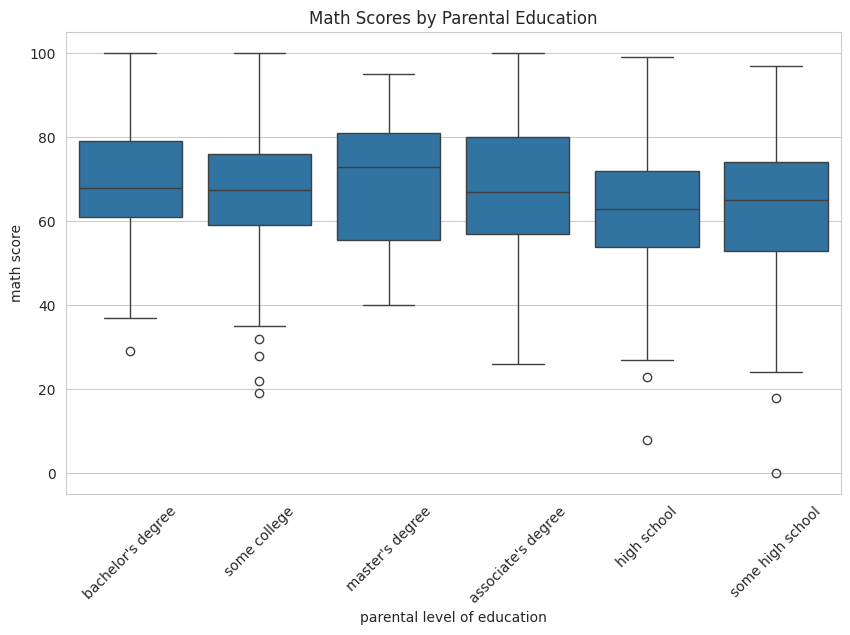

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='parental level of education',
    y='math score',
    data=df
)

plt.title('Math Scores by Parental Education')
plt.xticks(rotation=45)
plt.show()

##**Chart 2: Bar Chart (Test Preparation Comparison)**

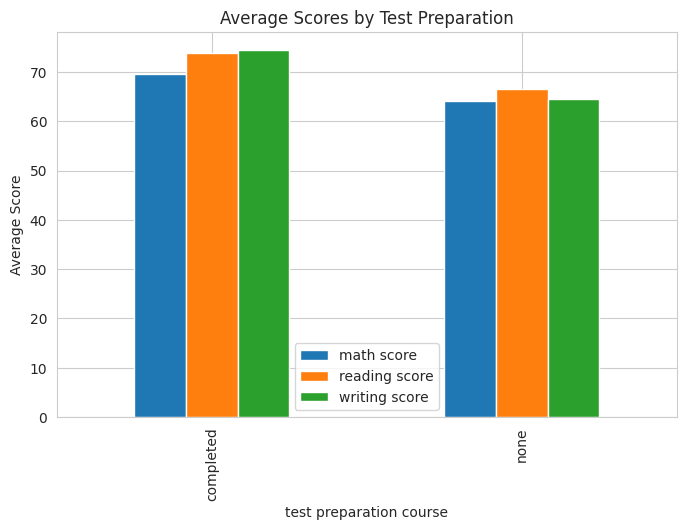

In [ ]:
prep_avg = df.groupby(
    'test preparation course'
)[['math score','reading score','writing score']].mean()

prep_avg.plot(kind='bar')

plt.title('Average Scores by Test Preparation')
plt.ylabel('Average Score')
plt.show()

##**Chart 3: Correlation Heatmap**

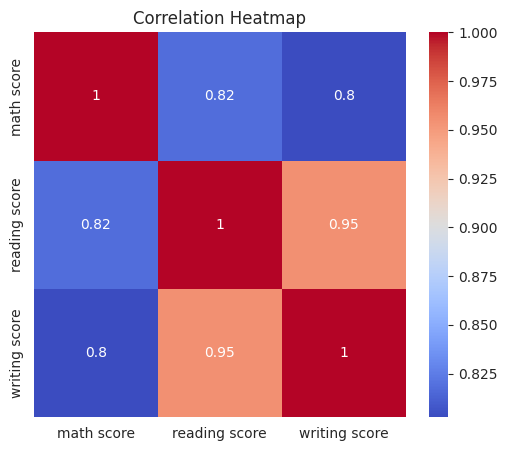

In [ ]:
plt.figure(figsize=(6,5))

sns.heatmap(
    df[['math score','reading score','writing score']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

##**Chart 4: Gender vs Subject**

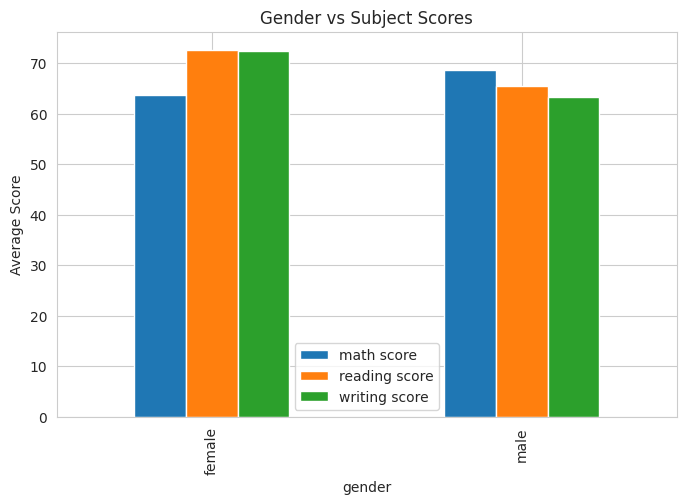

In [ ]:
gender_scores.plot(kind='bar')

plt.title('Gender vs Subject Scores')
plt.ylabel('Average Score')
plt.show()

##**Chart 5: Histogram of Total Scores**

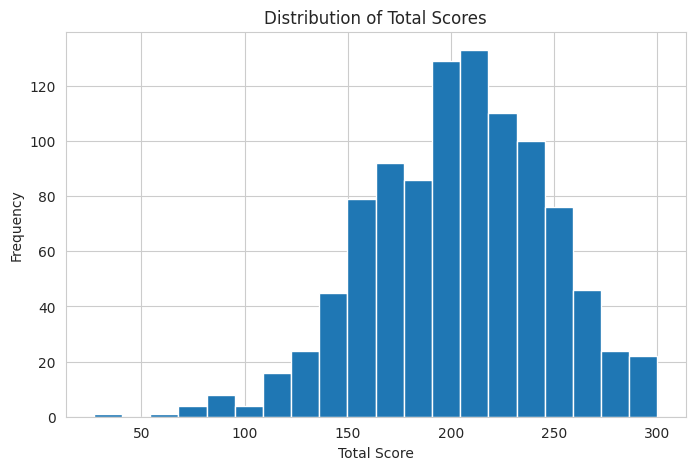

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df['total_score'], bins=20)

plt.title('Distribution of Total Scores')
plt.xlabel('Total Score')
plt.ylabel('Frequency')

plt.show()

##**Chart 6: Scatter Plot (Reading vs Math)**

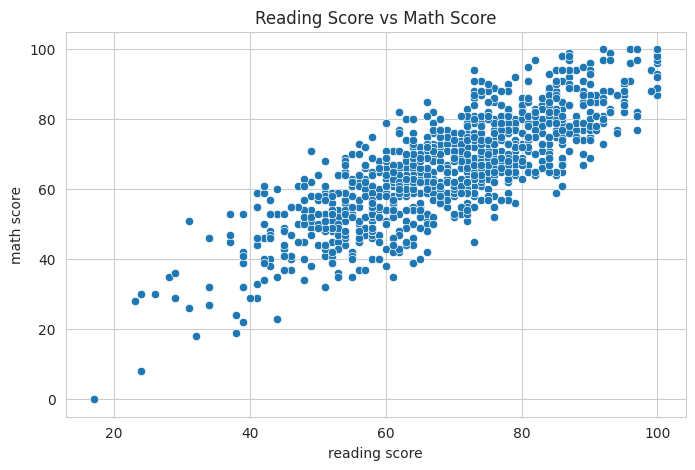

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='reading score',
    y='math score',
    data=df
)

plt.title('Reading Score vs Math Score')
plt.show()

# **AT-RISK STUDENT SEGMENTATION**

In [ ]:
#Define At-Risk Students (Students scoring below 50 in any subject)
at_risk = df[
    (df['math score'] < 50) |
    (df['reading score'] < 50) |
    (df['writing score'] < 50)
]

print("Total At-Risk Students:", len(at_risk))

Total At-Risk Students: 188


In [ ]:
#At-Risk Percentage by Gender
risk_gender = (
    at_risk.groupby('gender').size()
    /
    df.groupby('gender').size()
)*100

risk_gender

,0
gender,
female,17.181467
male,20.539419


In [ ]:
#At-Risk Percentage by Test Preparartion
risk_prep = (
    at_risk.groupby('test preparation course').size()
    /
    df.groupby('test preparation course').size()
)*100

risk_prep

,0
test preparation course,
completed,10.055866
none,23.676012


In [ ]:
#At-Risk Percentage by Parental Education
risk_parent = (
    at_risk.groupby('parental level of education').size()
    /
    df.groupby('parental level of education').size()
)*100

risk_parent.sort_values(ascending=False)

,0
parental level of education,
some high school,25.698324
high school,25.000000
some college,16.814159
associate's degree,14.864865
bachelor's degree,13.559322
master's degree,10.169492


In [ ]:
#At-Risk Segmentation Table
risk_table = pd.DataFrame({
    'Total Students': df.groupby('gender').size(),
    'At Risk Students': at_risk.groupby('gender').size()
})

risk_table['Risk %'] = (
    risk_table['At Risk Students']
    / risk_table['Total Students']
)*100

risk_table

,Total Students,At Risk Students,Risk %
gender,,,
female,518,89,17.181467
male,482,99,20.539419


In [ ]:
# Create Excel file
at_risk = df[
    (df['math score'] < 50) |
    (df['reading score'] < 50) |
    (df['writing score'] < 50)
]

at_risk.to_excel("At_Risk_Students.xlsx", index=False)

from google.colab import files
files.download("At_Risk_Students.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **STUDENT'S REPORT**

## **Overview**

The objective of this project was to analyze student performance data and identify factors affecting academic outcomes. The dataset was explored, cleaned, and visualized using Python to uncover trends in student scores, attendance, study habits, and other academic indicators.

## **Key Findings**

### **Academic Performance Distribution***

Most students achieved average scores in the mid-performance range, while a smaller group consistently performed either exceptionally well or poorly.

### **Impact of Attendance**

Students with higher attendance percentages generally achieved better academic results. Attendance showed a strong positive relationship with final scores.

### **Study Hours Influence**

Students dedicating more time to studying each week tended to obtain higher marks, indicating that study habits significantly affect performance.

### **At-Risk Students**

A subset of students exhibited:

* Low attendance
* Low study hours
* Below-average scores

These students were categorized as "At-Risk" and require academic intervention.

### **Performance Segmentation**

Students were classified into:

* High Performers
* Average Performers
* At-Risk Students

This segmentation helps educators provide targeted support and resources.

## **Conclusion**

Student success is strongly associated with attendance and study consistency. Early identification of at-risk students can improve overall academic performance through timely intervention and support.


# **MOST IMPACTFUL RECOMMENDATION**

The most impactful recommendation from this analysis is the implementation of an Early At-Risk Student Identification System.

By continuously monitoring attendance, study hours, and academic scores, the institution can identify struggling students before their performance declines significantly. Early intervention through mentoring, counseling, and academic support can help students improve outcomes and reduce failure rates.

This recommendation is particularly valuable because it addresses academic challenges proactively rather than reactively, leading to better student performance, higher retention rates, and improved overall educational quality.
